Install scikit-bio if you do not have it already.

In [1]:
pip install scikit-bio

Note: you may need to restart the kernel to use updated packages.


In [1]:
from skbio.diversity import alpha_diversity
import pandas as pd

Import rarefied OTU datasets that were previously generated in qiime2 and R.

In [2]:
BR19_OTU=pd.read_csv("BR19_OTUs_rarefied_copy.csv", index_col=0)
BR24_OTU=pd.read_csv("BR24_OTUs_rarefied_copy.csv", index_col=0)

In [3]:
#Import metadata? They are tsvs
BR19_md = pd.read_csv('BR_2019_metadata copy.tsv', index_col=0, sep='\t')
BR24_md = pd.read_csv('BR2024_metadata_F240_R220 copy.tsv', index_col=0, sep='\t')


Calculate alpha diversity metrics, Shannon Diversity and species observed

In [4]:
#shannon div
BR19shannon=alpha_diversity('shannon', BR19_OTU) 
BR24shannon=alpha_diversity('shannon', BR24_OTU)
print(BR19shannon)
print(BR24shannon)

#Sobs: an alpha diversity metric, number of taxon obs for each sample using the alpha_diversity driver function:
BR19sobs = alpha_diversity('sobs', BR19_OTU)
BR24sobs = alpha_diversity('sobs', BR24_OTU)

print(BR19sobs)
print(BR24sobs)


B0001_S1       5.214605
B0002_S2       4.574384
B0003_S3       5.147471
B0004_S4       5.016817
B0005_S5       5.298519
                 ...   
SB0455_S137    4.149897
SB0457_S139    5.052838
SB0458_S140    4.534120
SB0461_S143    4.547666
SB0465_S147    5.131017
Length: 334, dtype: float64
BR1B1001           4.655660
BR1B1002           4.514909
BR1B1004           4.721667
BR1B1006           4.657928
BR1B1007           4.628854
                     ...   
Br1Spi2PostS001    4.019725
Br1Spi2PostS002    4.439663
Br1Spi2PostS003    4.390861
Control14          2.329922
Control15          2.182752
Length: 309, dtype: float64
B0001_S1       301
B0002_S2       182
B0003_S3       293
B0004_S4       254
B0005_S5       317
              ... 
SB0455_S137    126
SB0457_S139    270
SB0458_S140    239
SB0461_S143    139
SB0465_S147    274
Length: 334, dtype: int64
BR1B1001           151
BR1B1002           144
BR1B1004           169
BR1B1006           163
BR1B1007           169
                  ... 

Combine both alpha diversity metrics, and then add that to the metadata

In [5]:
adiv19 = pd.concat([BR19shannon, BR19sobs], axis=1)
adiv19.columns = ['Shannon', 'Sobs']  

adiv24 = pd.concat([BR24shannon, BR24sobs], axis=1)
adiv24.columns = ['Shannon', 'Sobs']  

Combine alpha diversity and metadata. There are more samples in the metadata dataset because the alpha diversity was calculated from the rarefied OTUs, so drop samples that have no alpha diversity.

In [6]:
BR19_final = pd.concat([adiv19, BR19_md], axis=1)
BR19_final =BR19_final.dropna(subset=["Shannon"])
BR19_final.to_csv('BR19_final.csv')

BR24_final = pd.concat([adiv24, BR24_md], axis=1)
BR24_final =BR24_final.dropna(subset=["Shannon"])
BR24_final.to_csv('BR24_final.csv')

Now that the final datasets have been created, compare Shannon diversity and Sobs by port 1 vs port 4, pre vs post dosing, and 2019 vs 2024. Plot exploratory box and whisker plots.

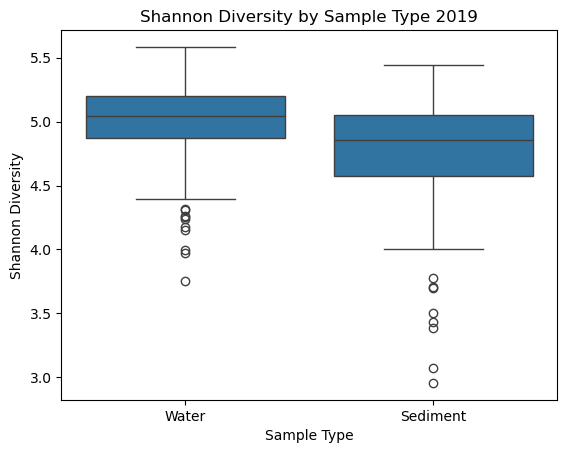

In [7]:
#2019 boxplots seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=BR19_final, x="SampleType", y="Shannon")

plt.xlabel("Sample Type")
plt.ylabel("Shannon Diversity")
plt.title("Shannon Diversity by Sample Type 2019")
plt.savefig("Shannon_SampleType_boxplot_2019.png") 
plt.show()



Try running a for loop?. Try to plot a boxplot of shannon diversity, differing by sample type, pre post, port. Will prob need to do year differently.

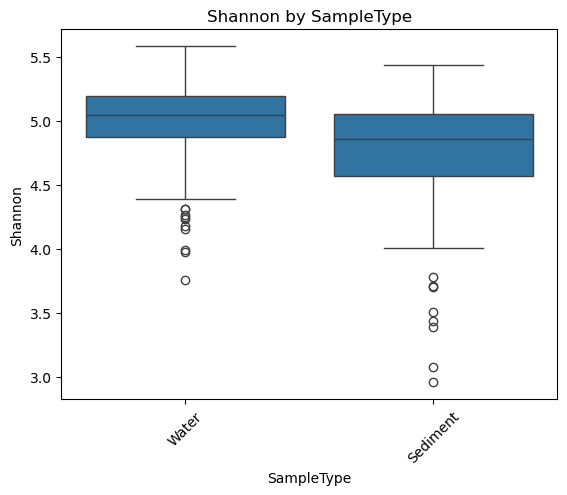

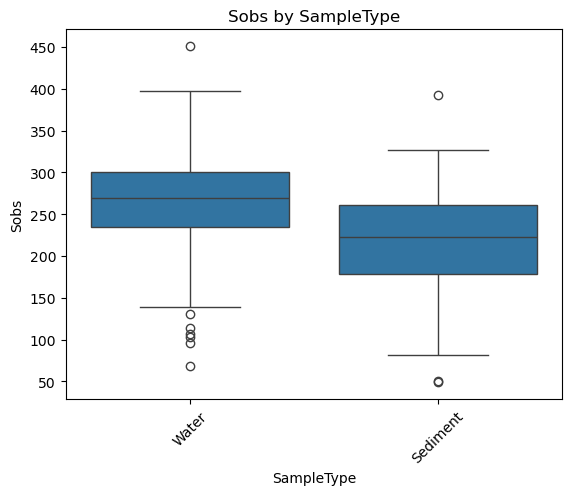

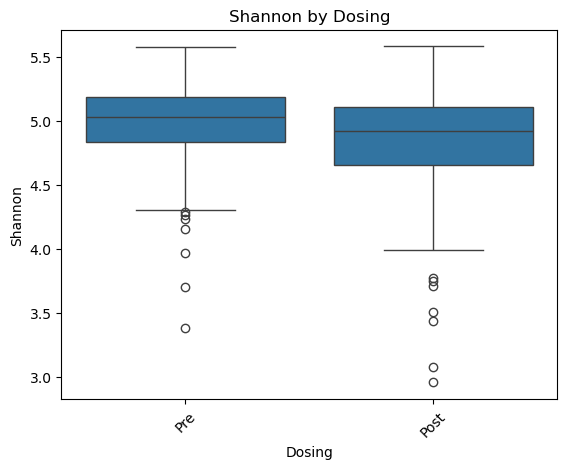

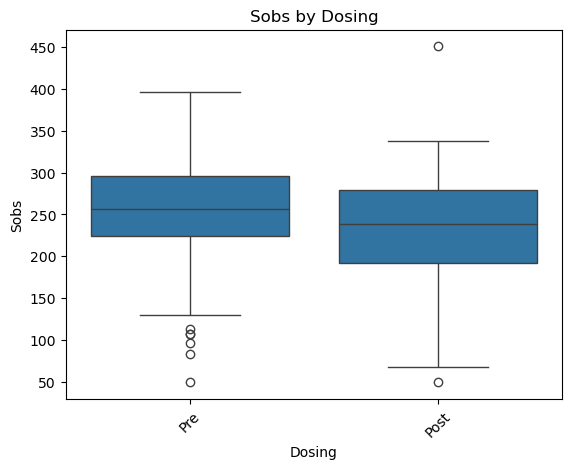

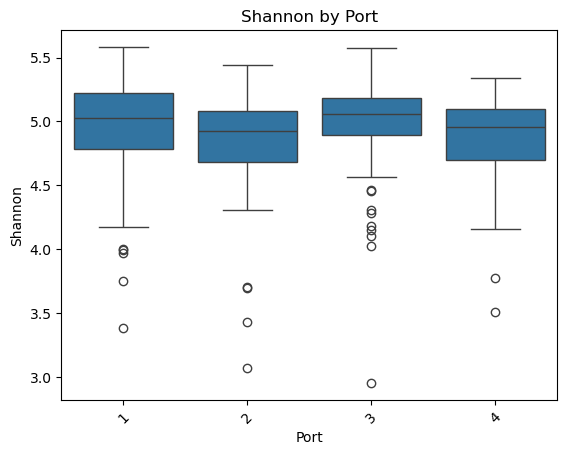

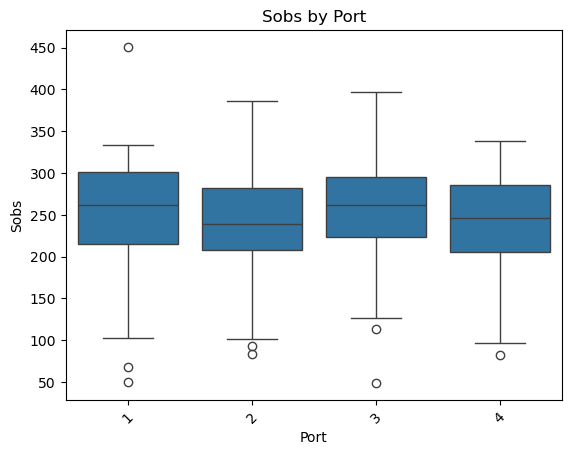

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_variables = ['Shannon', 'Sobs']

group_vars = ['SampleType', 'Dosing', 'Port']

for group in group_vars:
    for var in plot_variables:
        plt.figure()

        sns.boxplot(data=BR19_final, x=group, y=var)

        plt.xlabel(group)
        plt.ylabel(var)
        plt.title(f"{var} by {group}")
        plt.xticks(rotation=45)

        plt.show()

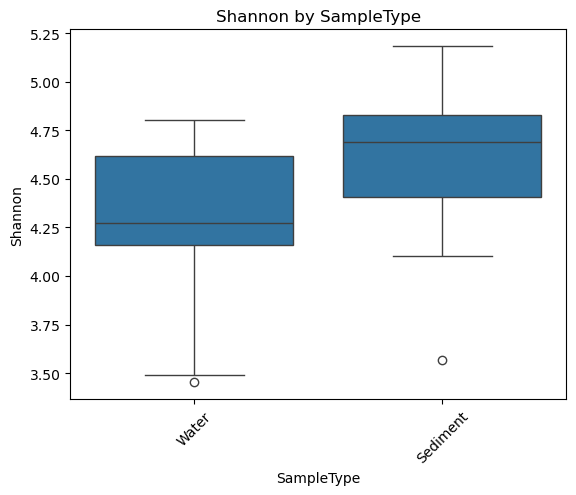

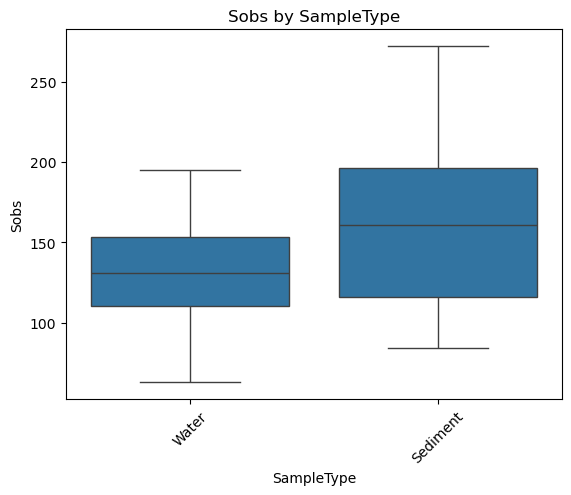

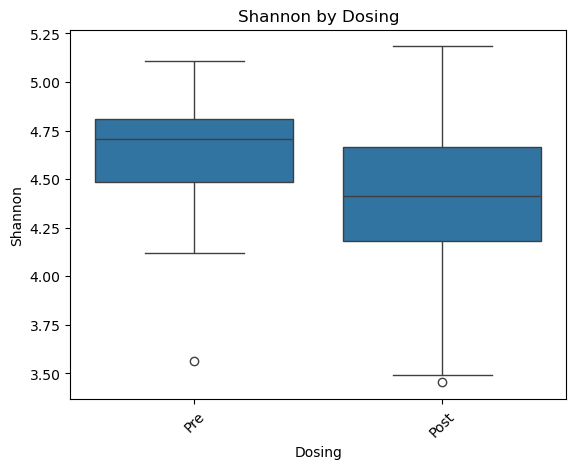

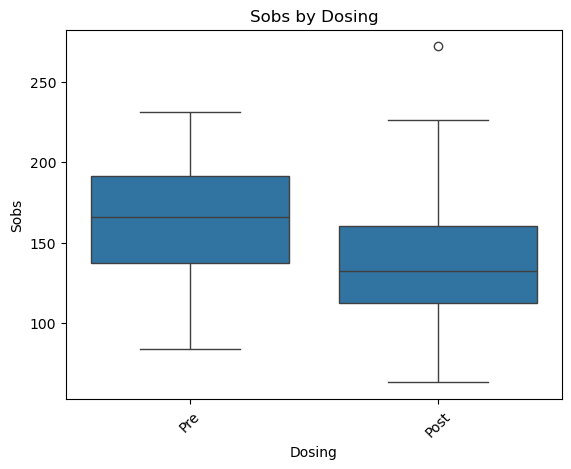

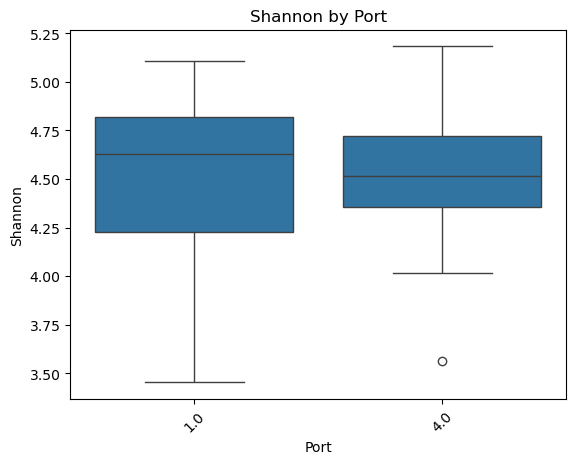

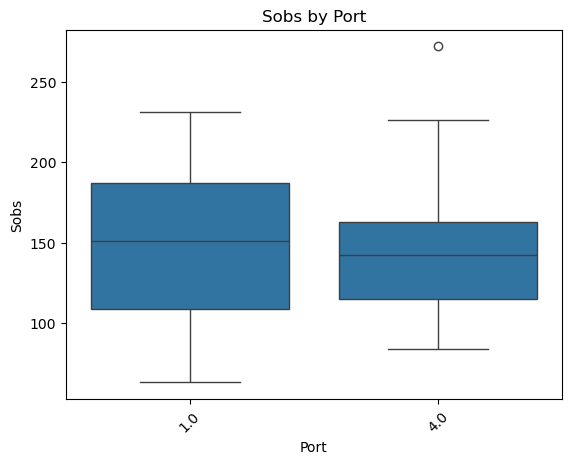

In [17]:
#Do same for 2024 data

plot_variables = ['Shannon', 'Sobs']

group_vars = ['SampleType', 'Dosing', 'Port']

for group in group_vars:
    for var in plot_variables:
        plt.figure()

        sns.boxplot(data=BR24_final, x=group, y=var)

        plt.xlabel(group)
        plt.ylabel(var)
        plt.title(f"{var} by {group}")
        plt.xticks(rotation=45)

        plt.show()

In [26]:
from scipy.stats import shapiro

print("BR19 Shannon", shapiro(BR19_final['Shannon']))
print("BR19 Sobs", shapiro(BR19_final['Sobs']))
print("BR24 Shannon", shapiro(BR24_final['Shannon']))
print("BR24 Sobs", shapiro(BR24_final['Sobs']))

#p value significant, so data not normally distributed


BR19 Shannon ShapiroResult(statistic=np.float64(0.8636087406586965), pvalue=np.float64(1.4849638876857445e-16))
BR19 Sobs ShapiroResult(statistic=np.float64(0.9738592978338027), pvalue=np.float64(9.48392845670778e-06))
BR24 Shannon ShapiroResult(statistic=np.float64(0.7595428679991516), pvalue=np.float64(6.120283627678839e-21))
BR24 Sobs ShapiroResult(statistic=np.float64(0.6696173702311649), pvalue=np.float64(4.089694361344592e-24))


In [28]:
from scipy.stats import mannwhitneyu

sediment = BR19_final[BR19_final["SampleType"] == "Sediment"]["Shannon"]
water = BR19_final[BR19_final["SampleType"] == "Water"]["Shannon"]

stat, p = mannwhitneyu(sediment, water, alternative="two-sided")

print("U statistic:", stat)
print("p-value:", p)
print("Sediment median:", sediment.median())
print("Water median:", water.median())
BR19_final["SampleType"].value_counts()


U statistic: 7981.0
p-value: 2.1667815379186773e-08
Sediment median: 4.859534464389117
Water median: 5.047792633813791


SampleType
Water       217
Sediment    117
Name: count, dtype: int64

In [30]:
sediment = BR24_final[BR24_final["SampleType"] == "Sediment"]["Shannon"]
water = BR24_final[BR24_final["SampleType"] == "Water"]["Shannon"]

stat, p = mannwhitneyu(sediment, water, alternative="two-sided")

print("U statistic:", stat)
print("p-value:", p)
print("BR24 Sediment median:", sediment.median())
print("BR24 Water median:", water.median())
BR24_final["SampleType"].value_counts()

U statistic: 580.0
p-value: 0.0008656400446154513
BR24 Sediment median: 4.687460940425812
BR24 Water median: 4.274001622951824


SampleType
Sediment    33
Water       23
Name: count, dtype: int64

In [ ]:
#try too loop mann whitney u test

In [29]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    BR19_final[BR19_final["SampleType"] == "Sediment"]["Sobs"],
    BR19_final[BR19_final["SampleType"] == "Water"]["Sobs"],
    alternative="two-sided"
)

print("U statistic:", stat)
print("p-value:", p)

U statistic: 6920.0
p-value: 6.948238227294257e-12


In [30]:
BR19_final['Shannon']

B0001_S1       5.214605
B0002_S2       4.574384
B0003_S3       5.147471
B0004_S4       5.016817
B0005_S5       5.298519
                 ...   
SB0455_S137    4.149897
SB0457_S139    5.052838
SB0458_S140    4.534120
SB0461_S143    4.547666
SB0465_S147    5.131017
Name: Shannon, Length: 334, dtype: float64